# 信贷违约预测 · 完整项目流程（main_pipeline）

**项目**：阿里线上数据分析实习——基于用户历史数据与行为特征，预测信贷违约概率，为金融机构风控决策提供支持。
**数据**：阿里天池信贷违约数据集（train 80 万条 + testA 20 万条，47 个字段，部分匿名/脱敏）。
**模型**：逻辑回归（基线）→ 随机森林 → XGBoost → LightGBM（随机搜索优化）→ 集成对比，最终选择 LightGBM。

本 Notebook 把 W1–W4 的成果整合成一条主线：

| 阶段 | 内容 | 对应交付 |
|---|---|---|
| 1 数据探索 | 业务理解、目标分布、EDA | 数据探索报告 |
| 2 数据预处理 | 缺失/异常/重复处理 | data_preprocessing.py |
| 3 特征工程 | 编码、变换、特征创建与选择 | feature_engineering.py |
| 4 模型构建与评估 | 三模型对比、多指标 | model_training.py |
| 5 模型优化 | 随机搜索、K 折、集成、SHAP | model_optimization.py |
| 6 最终评估 | 测试集成绩单、泛化、阈值选择 | model_final_eval.py |
| 6b 校准与决策 | 概率校准、单线扫描（方案①）、逐笔算账（方案②） | probability_calibration.py / threshold_sweep.py / expected_loss_framework.py |
| 6c 补充分析 | 头部区分度、时间外验证、人工复审带 | head_capture.py / oot_validation.py / review_band.py |
| 7 业务结论 | 阈值解读、给业务方的话 | 最终项目报告 |

**怎么用**：默认快速路径——读取 data/ 与 outputs/ 已有产物，全程约 3–5 分钟；每个阶段末尾标注了完整重跑脚本（耗时更长，但可复现每一步）。

**AI 工具说明**：本 Notebook 与 `scripts/` 下的脚本初稿借助 OpenAI Codex 桌面版（26.915.31945 / codex-cli 0.155.0-alpha.9.2）生成；处理逻辑、参数口径与验收标准由本人确定，输出经本人逐项核对，详见报告第 14 节。


## 0. 环境与项目结构

依赖见 `requirements.txt`（pandas / numpy / scikit-learn / xgboost / lightgbm / shap / streamlit 等），建议用项目 `.venv`。

In [1]:
# 环境检查
import sys
print("Python", sys.version.split()[0])
import pandas as pd, numpy as np
print("pandas", pd.__version__, "| numpy", np.__version__)
import sklearn
print("scikit-learn", sklearn.__version__)
for lib in ("xgboost", "lightgbm", "shap"):
    try:
        m = __import__(lib)
        print(lib, m.__version__)
    except ImportError:
        print(lib, "未安装")


Python 3.13.0


pandas 3.0.5 | numpy 2.5.2


scikit-learn 1.9.0
xgboost 3.4.1
lightgbm 4.7.0


shap 0.52.0


In [2]:
from pathlib import Path
import pandas as pd, numpy as np
from IPython.display import display, Image, Markdown

# 自动定位项目根目录（含 data/ 的上级目录）
BASE = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").is_dir()), Path.cwd())
DATA = BASE / "data"
OUT = BASE / "outputs"
print("项目根目录:", BASE)

# 项目结构（核心目录）
for name in ("scripts", "data", "outputs", "notebooks", "reports"):
    p = BASE / name
    print(f"{'✓' if p.exists() else '✗'} {name}/")


项目根目录: credit-default-risk-model
✓ scripts/
✓ data/
✓ outputs/
✓ notebooks/
✓ reports/


## 1. 数据探索（W1）

**业务问题**：给定申请人的历史与行为特征，估计其**违约概率**，据此决定审批/利率。
**目标变量**：`isDefault`（1=违约，0=正常）。**评估指标**：违约率仅 20%，类别不均衡，因此以 精确率 / 召回率 / F1 / AUC 为主，准确率为辅。

In [3]:
# 原始数据概览（train.csv 约 80 万行；首次读取需约 10-20 秒）
train_raw = pd.read_csv(DATA / "train.csv")
print("原始 train.csv:", train_raw.shape, "| testA.csv: 20 万行（无标签）")
print("\n目标变量分布（违约率 %.1f%%）:" % (train_raw["isDefault"].mean() * 100))
print(train_raw["isDefault"].value_counts(normalize=True).round(3))

miss = train_raw.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
print("\n缺失最多的 6 列:\n", miss.head(6))


原始 train.csv: (800000, 47) | testA.csv: 20 万行（无标签）

目标变量分布（违约率 20.0%）:
isDefault
0    0.8
1    0.2
Name: proportion, dtype: float64

缺失最多的 6 列:
 n11                 69752
employmentLength    46799
n8                  40271
n14                 40270
n13                 40270
n12                 40270
dtype: int64


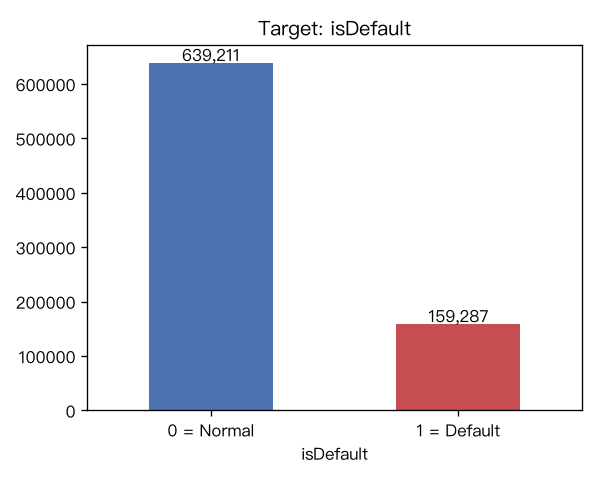

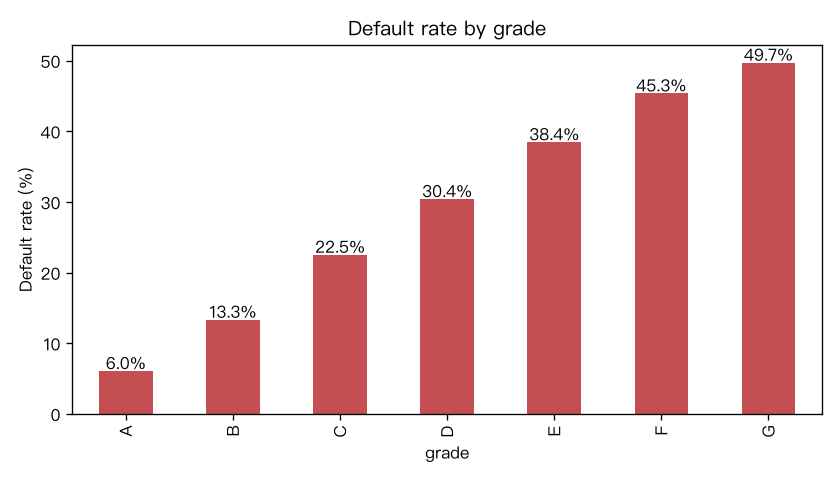

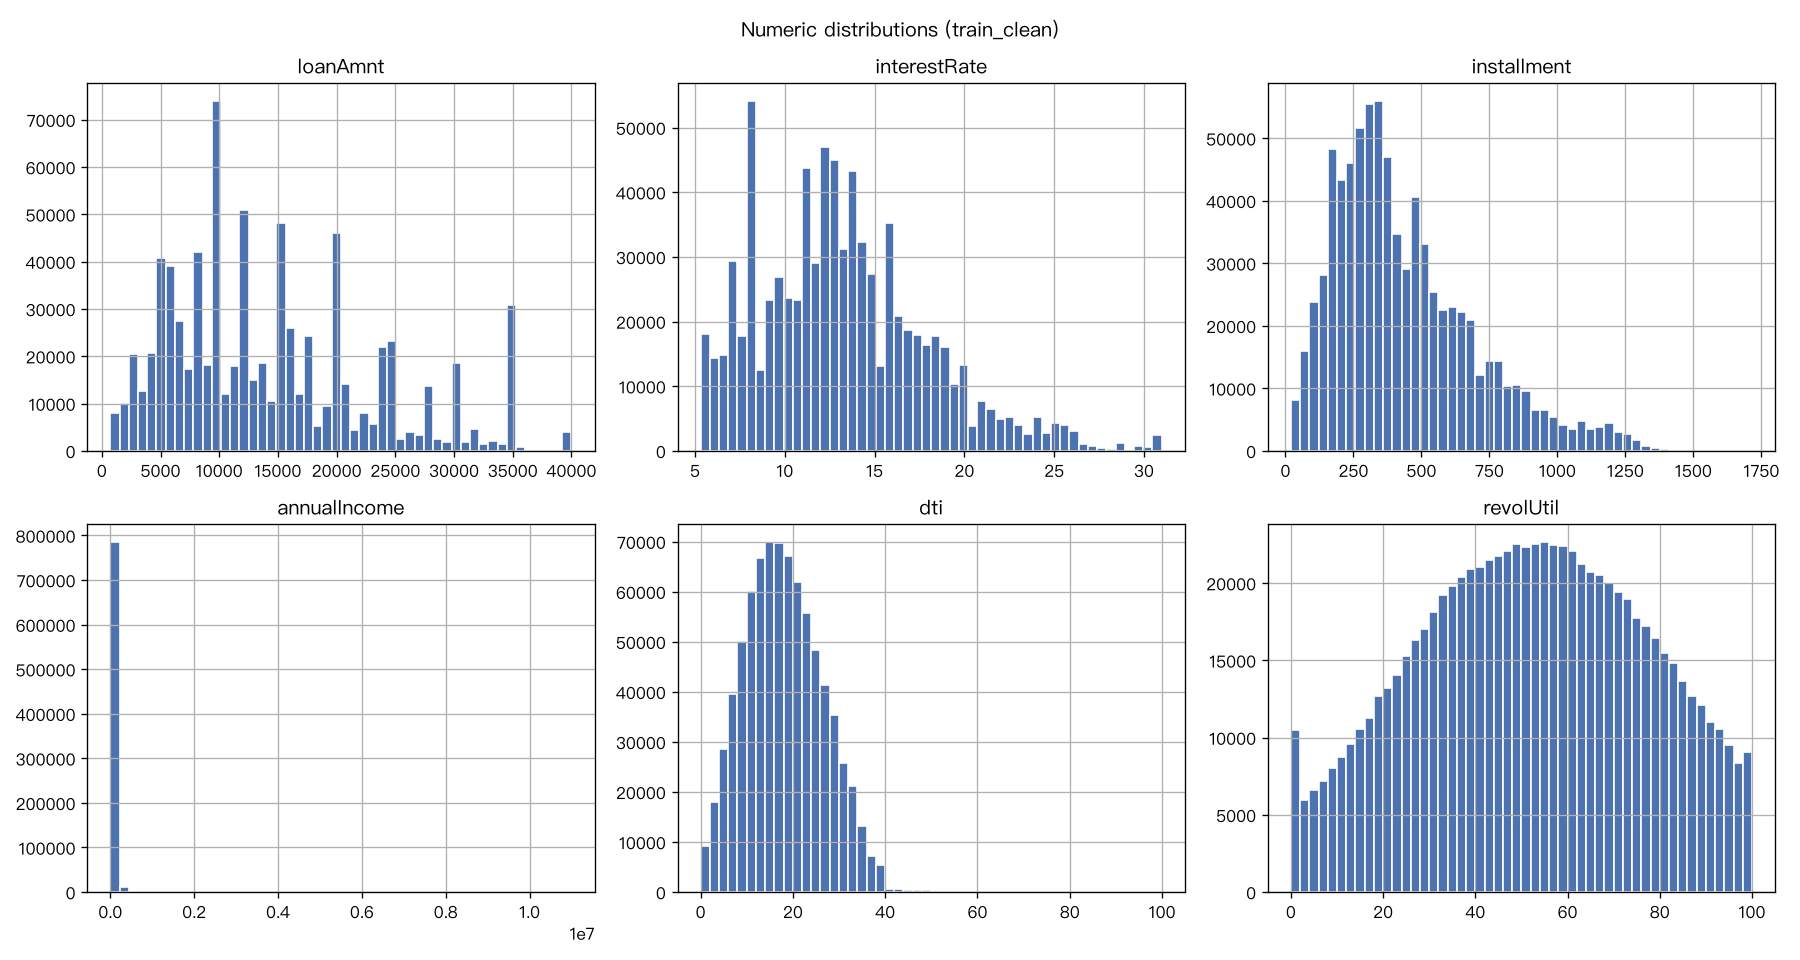

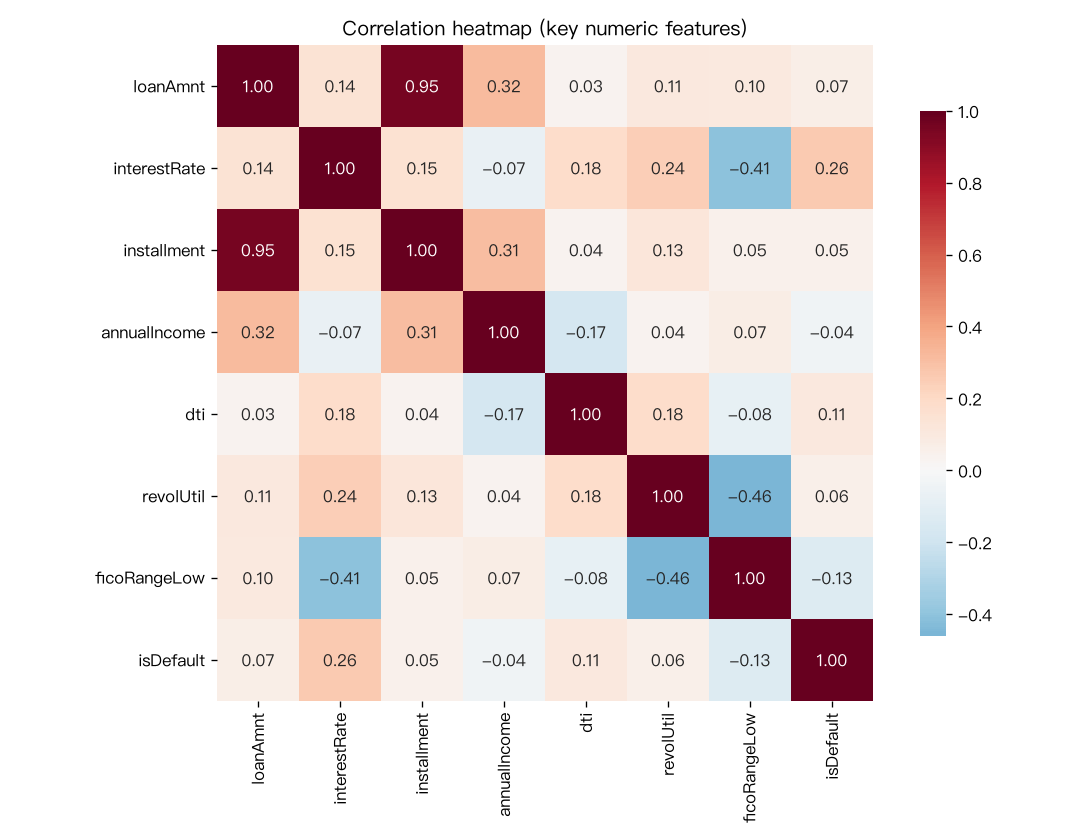

In [4]:
# W1 EDA 图（数据分布 / 相关性 / 等级违约率）
for f in ["eda_target_distribution.png", "eda_grade_default_rate.png",
          "eda_numeric_distributions.png", "eda_corr_heatmap.png"]:
    display(Image(str(OUT / "W1" / f), width=720))


In [5]:
# 数据质量报告（W1 输出）
print((OUT / "W1" / "data_quality_report.txt").read_text()[:1500])


信贷违约预测项目 - 数据质量检查报告

[1] 数据加载
train.csv: 800,000 行 x 47 列
testA.csv: 200,000 行 x 46 列
testA 比 train 少的列: ['isDefault']

[2] 列类型总览（train）
float64    33
int64       9
str         5

[3] 缺失值（train）
有缺失的列: 22/47，缺失格总数: 667,448
  n11: 69,752 (8.72%)
  employmentLength: 46,799 (5.85%)
  n8: 40,271 (5.03%)
  n14: 40,270 (5.03%)
  n13: 40,270 (5.03%)
  n12: 40,270 (5.03%)
  n9: 40,270 (5.03%)
  n0: 40,270 (5.03%)
  n1: 40,270 (5.03%)
  n2: 40,270 (5.03%)
  n3: 40,270 (5.03%)
  n5: 40,270 (5.03%)
  n6: 40,270 (5.03%)
  n7: 40,270 (5.03%)
  n10: 33,239 (4.15%)
  n4: 33,239 (4.15%)
  revolUtil: 531 (0.07%)
  pubRecBankruptcies: 405 (0.05%)
  dti: 239 (0.03%)
  title: 1 (0.00%)
  postCode: 1 (0.00%)
  employmentTitle: 1 (0.00%)

[4] 唯一性检查
train: 行数 800,000，id 唯一数 800,000，重复 id 0
test : 行数 200,000，id 唯一数 200,000，重复 id 0

[5] 目标变量 isDefault 分布
  isDefault=0: 640,390 (80.05%)
  isDefault=1: 159,610 (19.95%)

[6] 关键数值列 describe（min/max 看异常）
                       count          mean           std     

## 2. 数据预处理（W1）

**原则：修格子，不砍样本。** 缺失值优先填充（中位数/众数/业务占位），异常值按业务规则封顶或删除，仅删 1,502 行（0.19%），样本保留率 99.8%。

> 完整重跑：`.venv/bin/python scripts/data_preprocessing.py`（含检测报告与处理，约 1-2 分钟）

In [6]:
# 清洗前后对比
n_before = len(train_raw)
n_after = len(pd.read_csv(DATA / "train_clean.csv", usecols=["id"]))
print(f"清洗前 {n_before:,} 行 → 清洗后 {n_after:,} 行（删除 {n_before - n_after:,} 行 = 0.19%）")

clean_summary = pd.DataFrame({
    "处理项": ["annualIncome=0 视为缺失", "revolUtil>100 封顶", "dti 越界删行",
              "缺失极少列删行", "n0-n14 缺失", "employmentLength 缺失"],
    "处理方式": ["视为缺失并填充", "封顶到 100", "删除行", "删除行", "中位数填充", "填充'未知'"],
    "影响量": [229, 2719, 325, 1177, "—", 46375],
})
clean_summary


清洗前 800,000 行 → 清洗后 798,498 行（删除 1,502 行 = 0.19%）


,处理项,处理方式,影响量
0,annualIncome=0 视为缺失,视为缺失并填充,229
1,revolUtil>100 封顶,封顶到 100,2719
2,dti 越界删行,删除行,325
3,缺失极少列删行,删除行,1177
4,n0-n14 缺失,中位数填充,—
5,employmentLength 缺失,填充'未知',46375


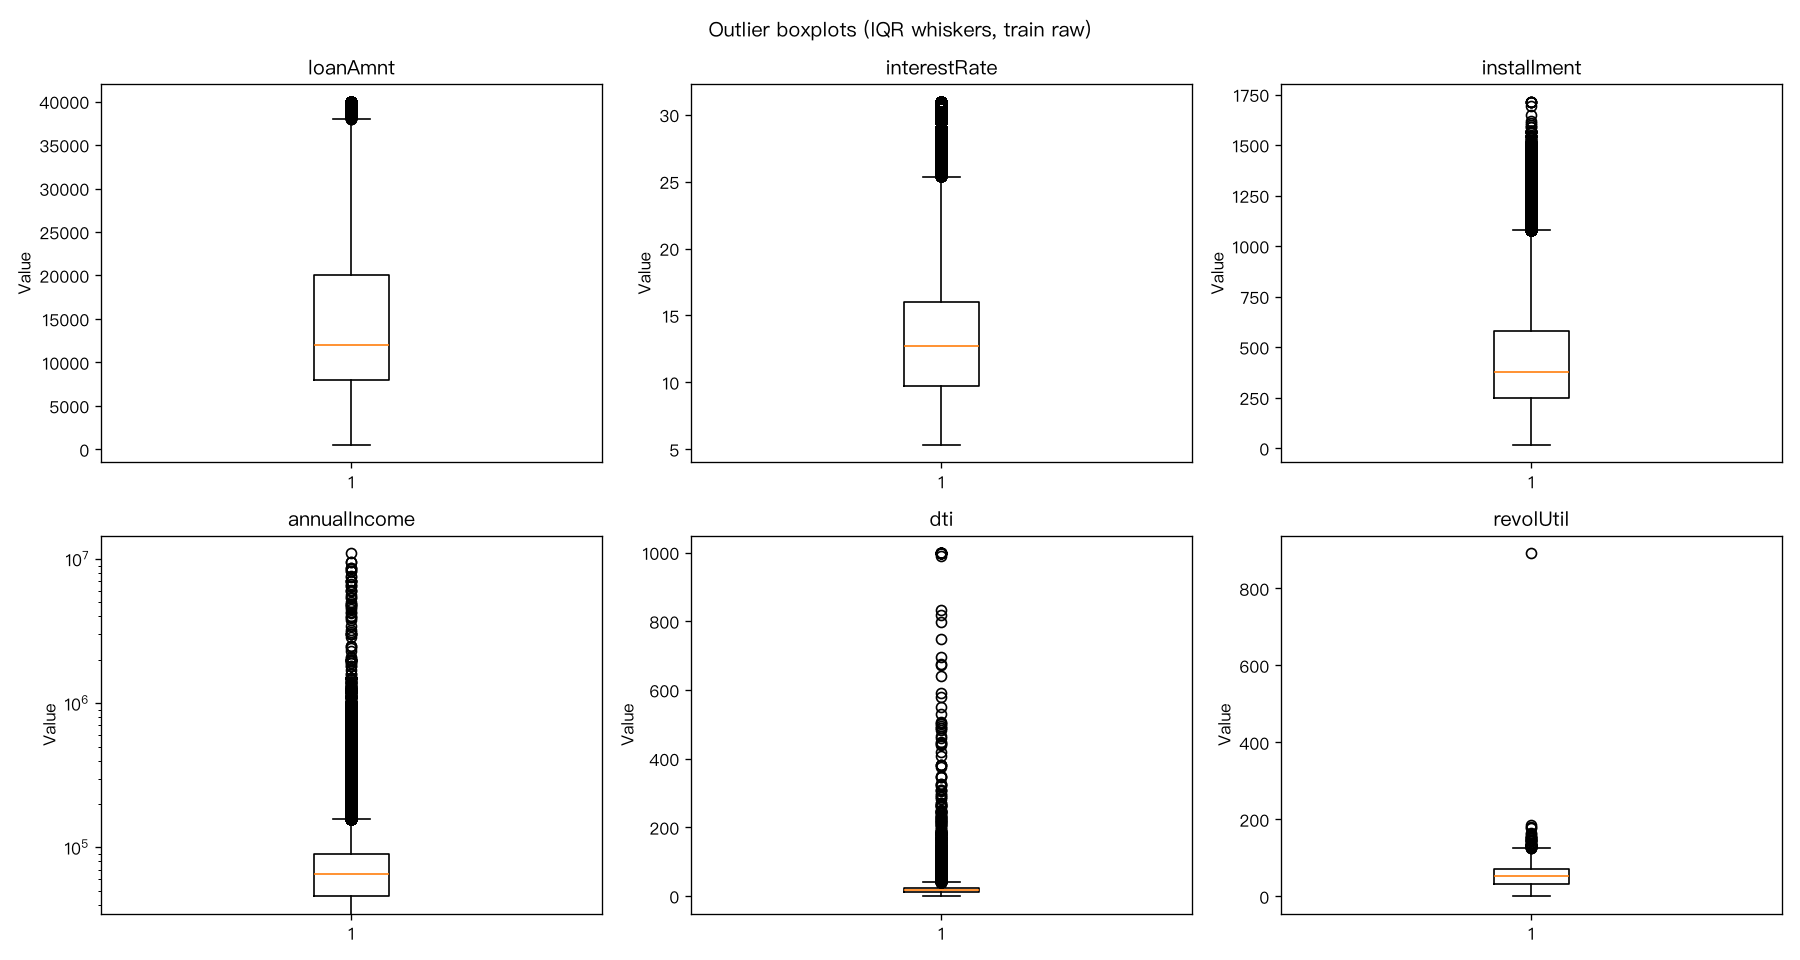

入 IQR 上界 = 156,600，极端样本 39,014 个，展示收入最高的 30 个：
  收入      贷款金额   循环余额      FICO下限  dti    违约
  10,999,200     5,000          534     685    0.1 0
   9,550,000    30,000          758     805    0.1 0
   9,522,972    35,000       28,120     710    0.3 0
   8,706,582     8,000       16,449     685    0.1 1
   8,700,000    14,000       12,664     685    0.2 0
   8,500,021    12,000       18,409     660    0.2 0
   8,300,000    28,000       17,019     675    0.2 0
   8,253,000    30,000       26,402     670    0.1 0
   7,600,000    10,000        2,494     700    0.1 0
   7,446,395    20,000       24,494     720    0.1 0
   7,000,055    26,000       39,796     720    0.2 0
   7,000,000     7,500        4,998     705    0.0 0
   7,000,000     1,200       18,600     685    0.1 0
   6,998,721    10,000       43,180     680    0.3 0
   6,693,021    25,000       21,090     685    0.3 0
   6,500,000    25,000        5,590     775    0.2 1
   6,500,000    12,000       12,949     730    0.1 0
   6,10

In [7]:
# 异常检测要点（先检测后处理：业务规则 + 3σ + IQR）
display(Image(str(OUT / "W1" / "outlier_boxplot.png"), width=720))
print((OUT / "W1" / "outlier_report.txt").read_text()[1500:3200])


## 3. 特征工程（W2）

四步（对应任务 3.1–3.4）：
1. **类别编码**：序数（grade/subGrade/employmentLength）、独热（homeOwnership/verificationStatus/purpose）、目标编码（regionCode，仅用训练集违约率防泄漏）
2. **数值变换**：右偏列 `log1p`（含年收入）；连续列 z-score 标准化
3. **特征创建**：`fico_avg`（上下限合并）、`credit_history_years`（信用历史长度）、`installment_income_ratio`（月供收入比）、2 个交互项（grade×dti、利率×金额）
4. **特征选择**：过滤法（相关系数）+ 嵌入法（随机森林重要性），60 列 → 保留 38 个

> 完整重跑：`.venv/bin/python scripts/W2/feature_engineering.py`（含随机森林重要性计算，约 1 分钟）

In [8]:
# 特征工程最终产物
df = pd.read_csv(DATA / "train_final.csv")
print("train_final.csv:", df.shape, "（38 个特征 + 目标 isDefault）")
print("违约率: %.1f%%" % (df["isDefault"].mean() * 100))

# 新增特征清单（W2 创建）
new_feats = ["fico_avg", "credit_history_years", "installment_income_ratio",
             "grade_dti_inter", "interest_loan_inter"]
print("\nW2 新增特征:", new_feats)
print("删除列（无信息/高基数）: id, policyCode, employmentTitle, postCode, title")


train_final.csv: (798498, 39) （38 个特征 + 目标 isDefault）
违约率: 19.9%

W2 新增特征: ['fico_avg', 'credit_history_years', 'installment_income_ratio', 'grade_dti_inter', 'interest_loan_inter']
删除列（无信息/高基数）: id, policyCode, employmentTitle, postCode, title


In [9]:
# 特征重要性（W2：随机森林嵌入法）
imp = pd.read_csv(OUT / "W2" / "feature_importance.csv", index_col=0)
imp.head(10)


,importance
subGrade_enc,0.188147
interestRate,0.133830
grade_enc,0.109169
term,0.069312
grade_dti_inter,0.045444
installment_income_ratio,0.041965
fico_avg,0.035953
dti,0.033241
interest_loan_inter,0.033165
installment_log,0.023934


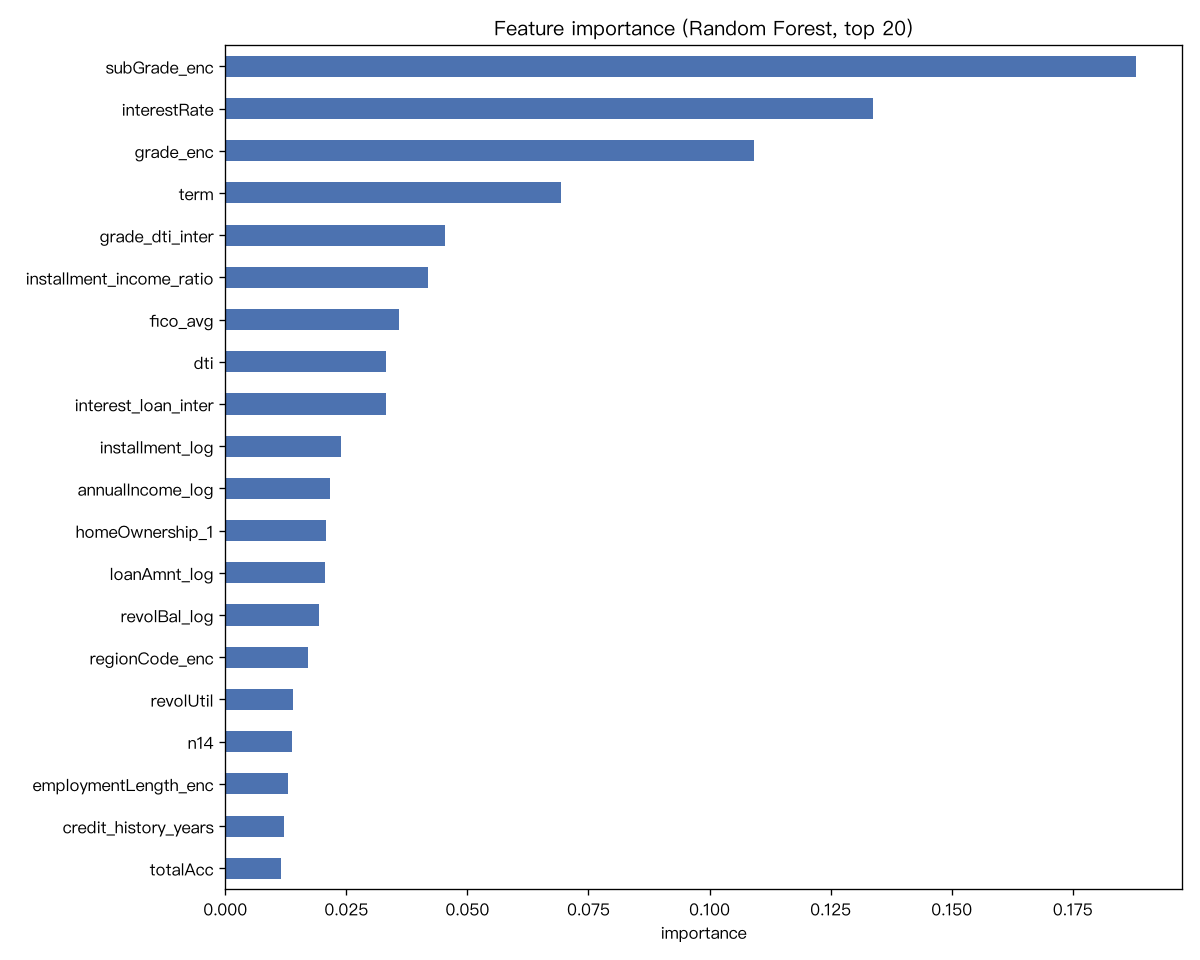

In [10]:
display(Image(str(OUT / "W2" / "feature_importance.png"), width=720))


### 3.5 延伸实验：38 个特征都用得上吗？（W4）

特征选择解决了"该不该留"，业务方还会问：**38 个是不是都得采集？少放几个会掉多少？**
做法：按 W2 随机森林重要性从高到低排序，依次只喂前 N 个特征、重训同一个 LGB，
比较验证集 AUC。**本实验只看训练集与验证集，测试集全程不参与。**

> 完整重跑：`.venv/bin/python scripts/W4/feature_count_auc.py`（9 档特征各训一次，约 40 秒）

,使用特征数,训练集 AUC,验证集 AUC,训练秒数
0,3,0.6974,0.7005,2.3
1,5,0.7097,0.7074,2.4
2,8,0.7198,0.7127,2.7
3,10,0.7221,0.7131,2.7
4,15,0.7317,0.7205,3.2
5,20,0.7385,0.7253,4.0
6,25,0.7414,0.7284,4.4
7,30,0.7419,0.7284,4.6
8,38,0.7432,0.7294,5.2


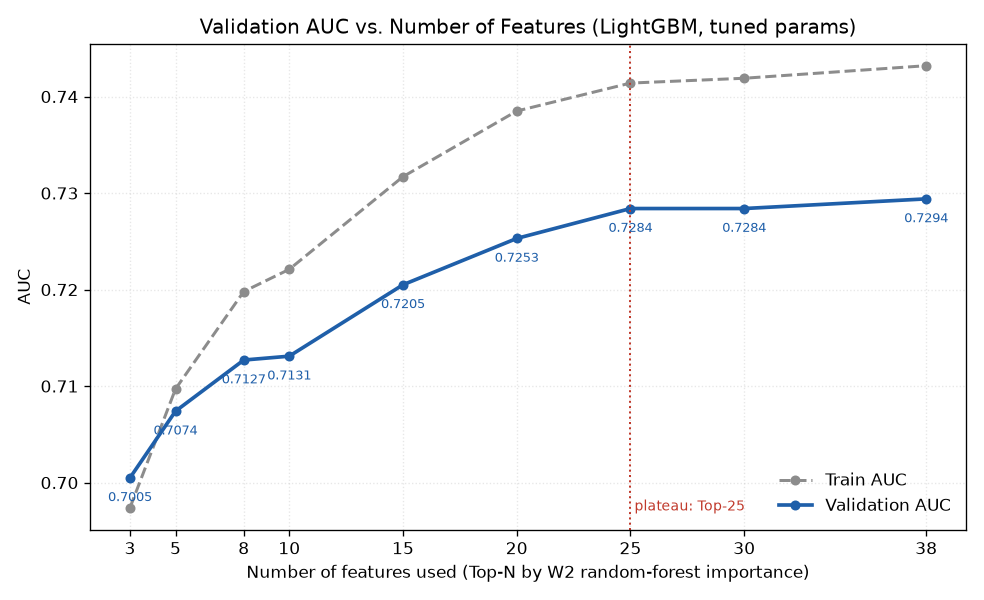

In [11]:
# 特征数量 vs 验证集 AUC
fc = pd.read_csv(OUT / "W4" / "feature_count_auc.csv")
display(fc[["n_features", "train_auc", "val_auc", "seconds"]].rename(columns={
    "n_features": "使用特征数", "train_auc": "训练集 AUC",
    "val_auc": "验证集 AUC", "seconds": "训练秒数"}))
display(Image(str(OUT / "W4" / "feature_count_auc.png"), width=760))


**结论**：3 个特征（子等级、利率、等级）就拿到满血性能的 96%——机构自己的风险判断最值钱；
20 个到 99.4%；**25 个之后饱和**（25→30 一点没涨，25→38 只 +0.0010）。
训练分一路涨（0.697→0.743）、验证分早早走平，说明后面的特征更多在帮模型"背训练集"。

**业务含义**：最终保留 38 个（数据已在手，不增加线上成本）；但若将来要精简采集口径，
砍到 Top 20–25 个、AUC 损失不到 0.005，是有数字支撑的方案。这也顺带回答了"为什么不做 RFE"——
RFE 想找的"最优特征数"，几条曲线就够回答，成本只要几十秒。

## 4. 模型构建与评估（W2）

**数据集划分（4.1）**：训练 70% / 验证 20% / 测试 10%，按目标变量分层，保证三集违约率都约 20%。
**基础模型（4.2）**：逻辑回归（线性基线）、随机森林、XGBoost。类别不均衡处理：LR/RF 用 `class_weight="balanced"`，XGB 用 `scale_pos_weight`。
**评估（4.3）**：准确率 / 精确率 / 召回率 / F1 / AUC。

> 完整重跑：`.venv/bin/python scripts/W2/model_training.py`（80 万行三模型，约 3-5 分钟）

In [12]:
# W2 验证集三模型对比（index 为模型名）
comp_w2 = pd.read_csv(OUT / "W2" / "model_comparison.csv", index_col=0)
comp_w2.round(4)


,accuracy,precision,recall,f1,auc
Logistic Regression,0.6582,0.3241,0.6572,0.4341,0.7189
Random Forest,0.6507,0.3208,0.6723,0.4343,0.7198
XGBoost,0.6559,0.3259,0.6785,0.4403,0.7276


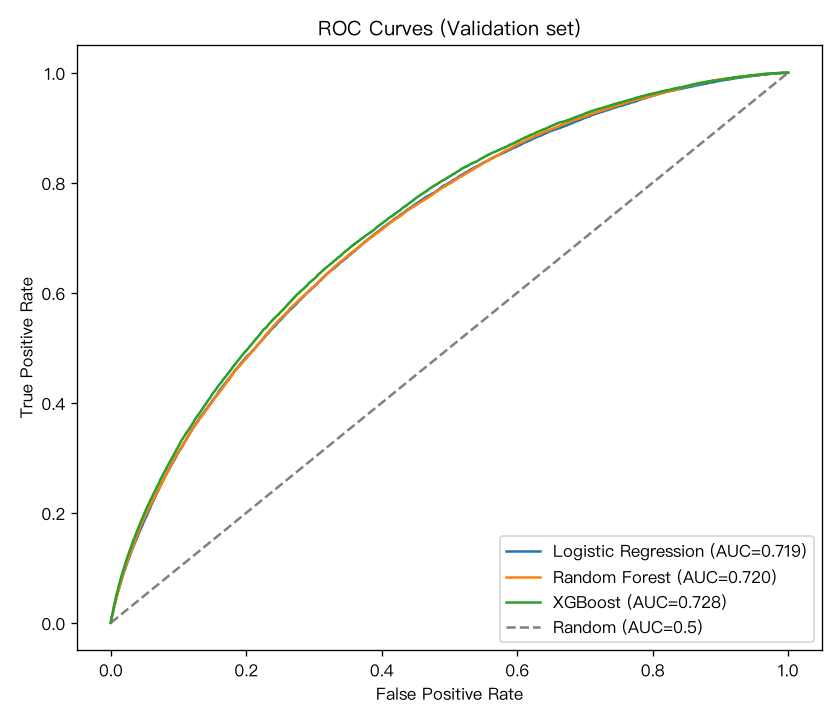

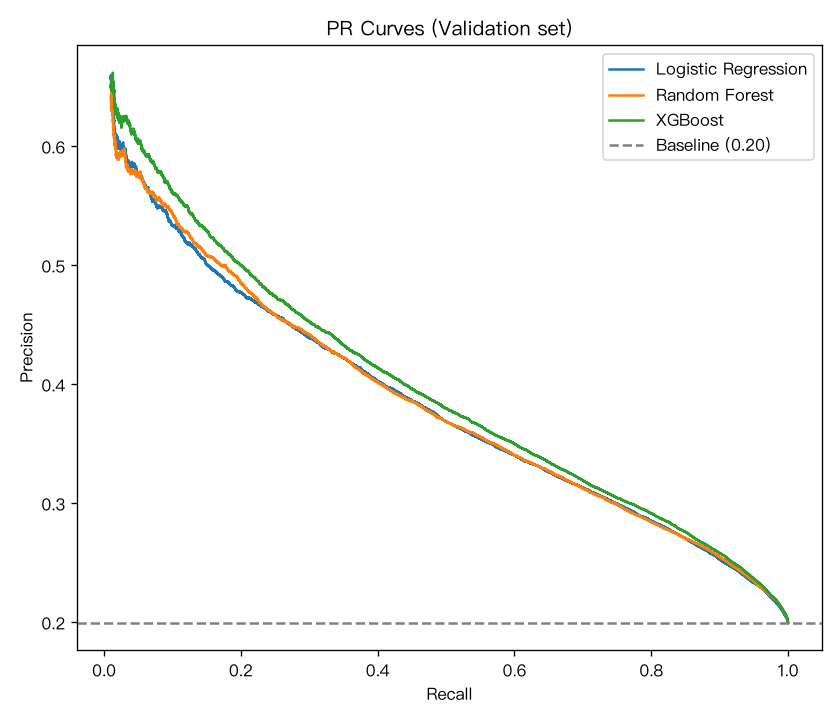

In [13]:
# ROC / PR 曲线（三模型对比）
display(Image(str(OUT / "W2" / "roc_curves.png"), width=720))
display(Image(str(OUT / "W2" / "pr_curves.png"), width=720))


**怎么看这张对比表**：违约率 20% 下，准确率参考意义有限（全猜"正常"也有 80%）。更看 AUC（排序能力）与召回率（能不能抓住违约者）。树模型（RF/XGB）明显优于线性 LR，说明特征与目标之间以非线性关系为主。

## 5. 模型优化（W3）

1. **随机搜索调参**（5 折交叉验证）：XGBoost 与 LightGBM 各 8 组参数组合，按验证集 AUC 取最优
2. **模型集成**：投票法 + Stacking（元模型处理类别不均衡），与单模型对比
3. **可解释性**：SHAP 全局特征归因

> 完整重跑：`.venv/bin/python scripts/W3/model_optimization.py`（含随机搜索与 SHAP，约 10-15 分钟）

In [14]:
# W3 优化后对比（7 个候选）
comp_w3 = pd.read_csv(OUT / "W3" / "model_comparison_optimized.csv")
comp_w3.round(4)


,model,accuracy,precision,recall,f1,auc
0,Stacking(集成),0.6553,0.3267,0.6860,0.4426,0.7298
1,LGB(优化),0.6566,0.3271,0.6825,0.4422,0.7294
2,XGB(优化),0.6636,0.3301,0.6672,0.4417,0.7286
3,Voting(集成),0.6601,0.3280,0.6708,0.4405,0.7276
4,XGB(基线),0.6559,0.3259,0.6785,0.4403,0.7276
5,RF(基线),0.6507,0.3208,0.6723,0.4343,0.7198
6,LR(基线),0.6582,0.3241,0.6572,0.4341,0.7189


In [15]:
# 随机搜索记录（前 6 组）
rs = pd.read_csv(OUT / "W3" / "random_search_results.csv")
rs.head(6)


,model,mean_cv_auc,std_cv_auc,params
0,XGBoost,0.724743,0.000380,"{'subsample': 0.8, 'n_estimators': 200, 'min_c..."
1,XGBoost,0.724316,0.000433,"{'subsample': 0.8, 'n_estimators': 200, 'min_c..."
2,XGBoost,0.723304,0.000313,"{'subsample': 1.0, 'n_estimators': 200, 'min_c..."
3,XGBoost,0.722538,0.000211,"{'subsample': 0.7, 'n_estimators': 100, 'min_c..."
4,XGBoost,0.720287,0.000401,"{'subsample': 0.7, 'n_estimators': 100, 'min_c..."
5,XGBoost,0.718169,0.000709,"{'subsample': 1.0, 'n_estimators': 200, 'min_c..."


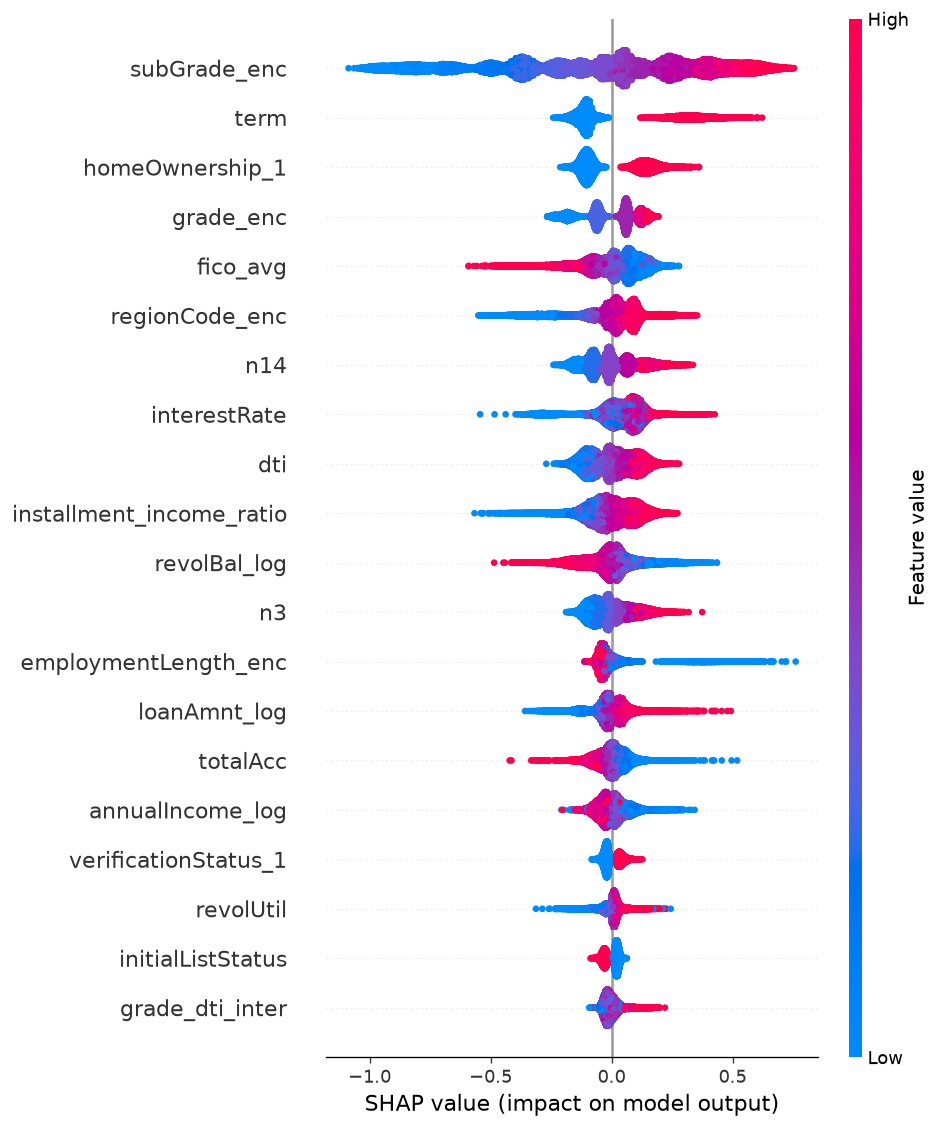

,mean_abs_shap
subGrade_enc,0.335357
term,0.164597
homeOwnership_1,0.122118
grade_enc,0.098953
fico_avg,0.090969
regionCode_enc,0.085667
n14,0.082834
interestRate,0.077398
dti,0.077202
installment_income_ratio,0.075680


In [16]:
# SHAP 全局归因
display(Image(str(OUT / "W3" / "shap_summary.png"), width=760))
shap_imp = pd.read_csv(OUT / "W3" / "shap_feature_importance.csv", index_col=0)
shap_imp.head(10)


**结论**：Stacking 验证集 AUC 0.7298 与 LightGBM（优化）0.7294 几乎持平，但 LGB 更可解释、部署简单，故选 **LightGBM(优化)** 为最终模型。

**最终参数**：`subsample=0.8, num_leaves=63, n_estimators=200, max_depth=8, learning_rate=0.05, colsample_bytree=0.7`

## 6. 最终评估（W4）

**纪律**：测试集（79,850 人）从 W1 起全程未参与任何建模决策；最终模型训练完才碰它，保证成绩单可信。
**验证方法**：训练/验证/测试三集 AUC 对比（泛化分析）+ 学习曲线（是否过拟合、加数据是否还有用）。

> 完整重跑：`.venv/bin/python scripts/W4/model_final_eval.py`、`scripts/W4/learning_curve.py`

In [17]:
# 测试集最终成绩单（阈值 0.5）
pd.read_csv(OUT / "W4" / "model_final_metrics.csv").round(4)


,accuracy,precision,recall,f1,auc
0,0.656,0.3254,0.6749,0.439,0.7249


In [18]:
# 泛化对比 + 阈值对照
gen = pd.read_csv(OUT / "W4" / "generalization_compare.csv", index_col=0)
print("训练 / 验证 / 测试 AUC 差距小 → 无明显过拟合")
display(gen.round(4))
print("\n阈值对照（0.3-0.7）:")
pd.read_csv(OUT / "W4" / "threshold_table.csv").round(3)


训练 / 验证 / 测试 AUC 差距小 → 无明显过拟合


,accuracy,precision,recall,f1,auc
train,0.6633,0.3352,0.6999,0.4533,0.7432
val,0.6566,0.3271,0.6825,0.4422,0.7294
test,0.6560,0.3254,0.6749,0.4390,0.7249



阈值对照（0.3-0.7）:


,threshold,precision,recall,f1,default_rate
0,0.3,0.245,0.923,0.388,0.751
1,0.4,0.281,0.828,0.420,0.587
2,0.5,0.325,0.675,0.439,0.414
3,0.6,0.386,0.475,0.426,0.245
4,0.7,0.474,0.262,0.337,0.110


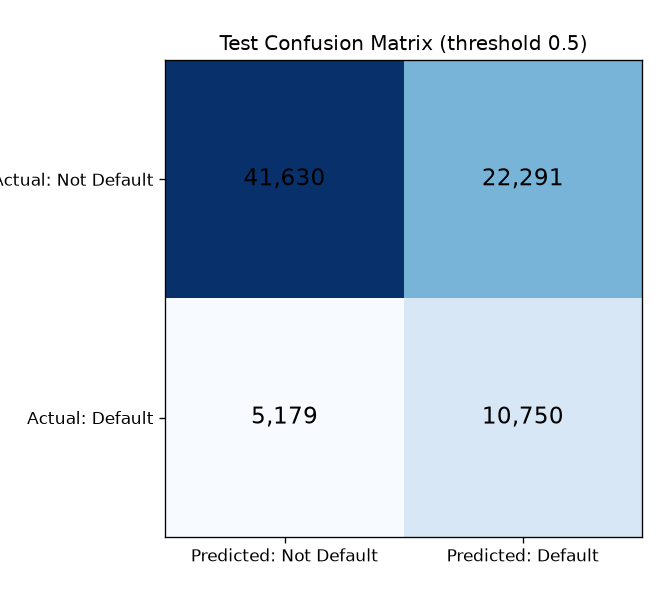

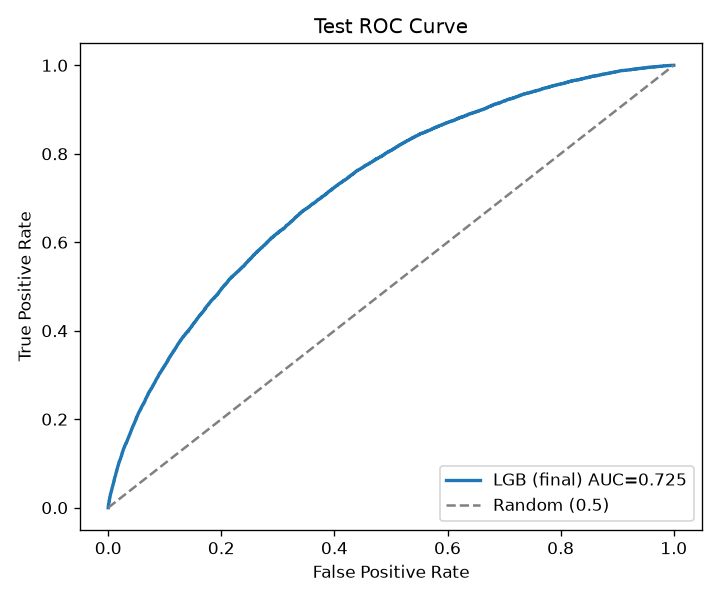

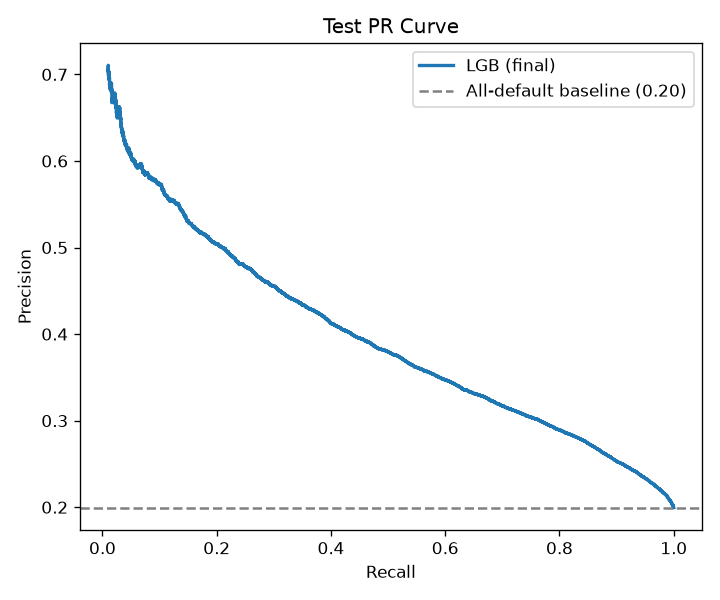

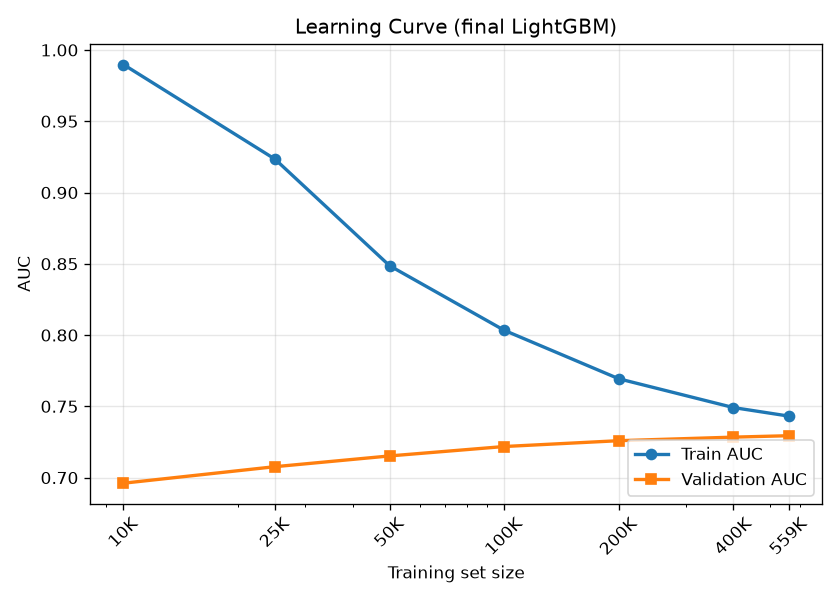

In [19]:
# 测试集可视化：混淆矩阵 / ROC / PR / 学习曲线
for f in ["confusion_matrix_test.png", "roc_curve_test.png",
          "pr_curve_test.png", "learning_curve.png"]:
    display(Image(str(OUT / "W4" / f), width=720))


,stage,brier,auc,mean_pred,share_ge_0.5
0,raw(test),0.2106,0.7249,0.4495,0.4138
1,isotonic(test),0.1425,0.7248,0.1993,0.0413
2,platt(test),0.1424,0.7249,0.1993,0.0343
3,actual(test),NaN,NaN,0.1995,NaN


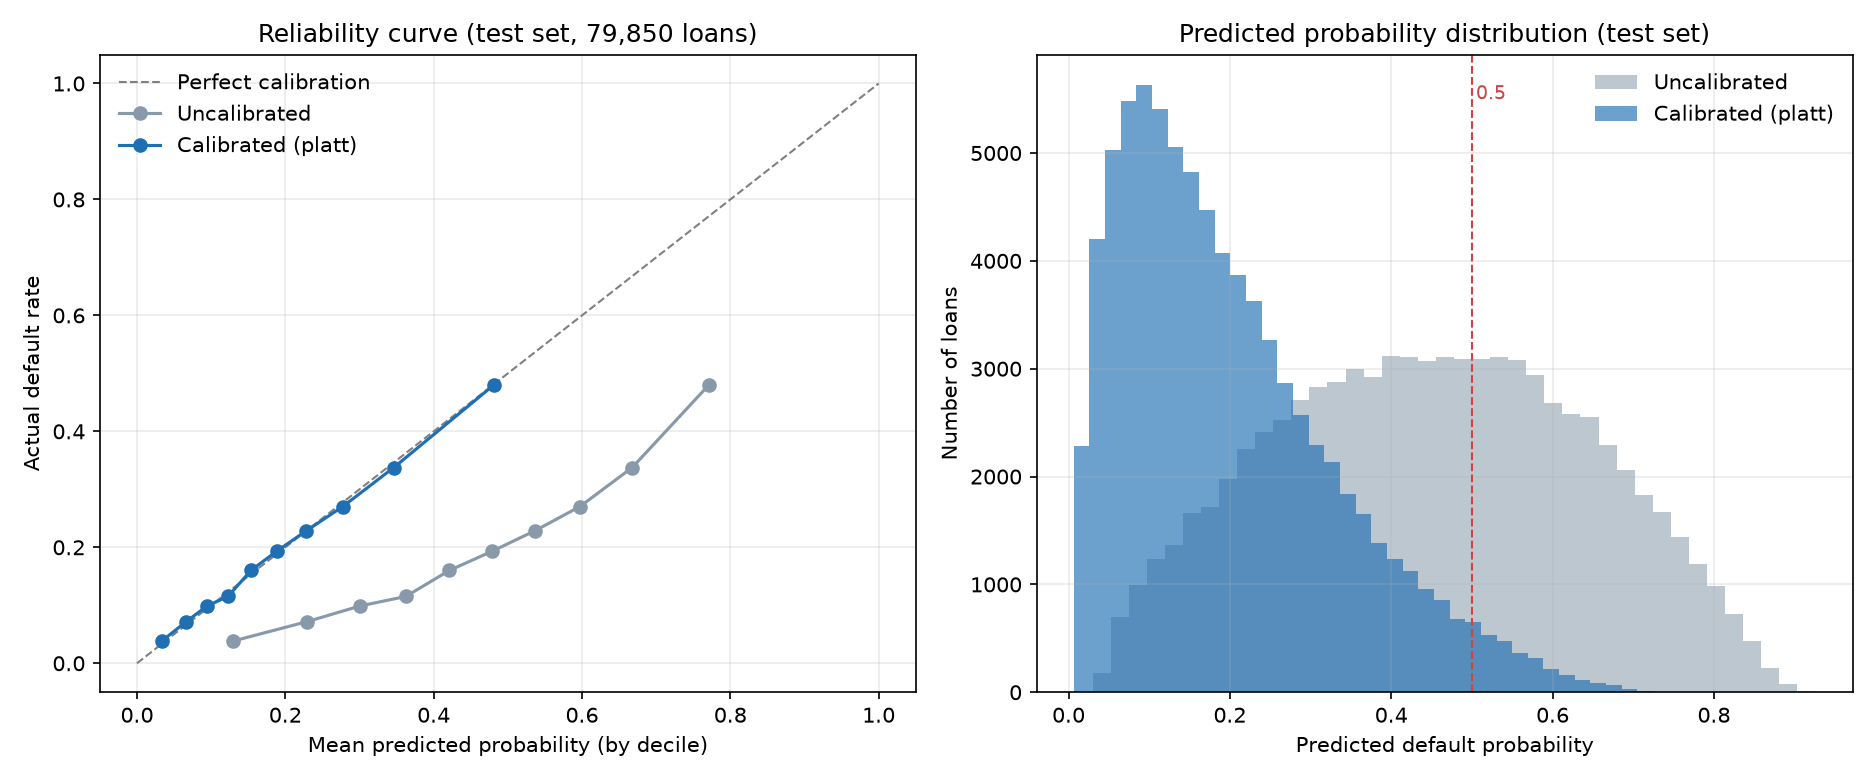

In [20]:
# 概率校准：把"分数"变成能直接算钱的"真实概率"
cal = pd.read_csv(OUT / "W4" / "calibration_compare.csv")
display(cal[["stage", "brier", "auc", "mean_pred", "share_ge_0.5"]].round(4))
display(Image(str(OUT / "W4" / "calibration_curve.png"), width=720))


**为什么要校准**：模型原始概率排序很准，但数值整体虚高——平均说 45%，实际违约率只有 20%（虚高 125%）。
直接拿它算"期望损失 = 概率 × 金额 × (1−回收率)"会高估损失，把该放的好客户也拒掉。
校准后平均概率 0.1993 ≈ 实际 0.1995，Brier 从 0.2106 降到 0.1424，而 **AUC 不变**（0.7249）——
校准只动"数值大小"，不动"谁排前面"。方法在验证集内部对半选出：Isotonic 与 Platt 差万分之几，取更平滑的 Platt。

### 6.1 放贷方案① 单线扫描：一条线管所有人

业务方要拍板的只有一件事：这笔钱放还是不放。最省事的做法是一条阈值线——概率过线就拒：只认排序，一条线管所有人，换个客群也照搬得过来；代价是金额、期限、利率都不进规则。
W3 周报承诺过 W4 会给不同阈值的对照表，这里补成完整曲线（0 到 1 按 0.001 步长扫一遍），拒绝率和钱一起给。

> 完整重跑：`.venv/bin/python scripts/W4/threshold_sweep.py`、`scripts/W4/threshold_select_on_val.py`

,阈值,被拒占比,拦截率,被拒者精确率,总期望利润(万元),净增益_实现值(万元)
299,0.300,0.7511,0.9233,0.2452,3563.8622,1566.4604
399,0.400,0.5872,0.8284,0.2814,5119.3375,3126.0877
499,0.500,0.4138,0.6749,0.3254,6155.0407,3979.7526
549,0.550,0.3268,0.5791,0.3535,6340.4677,4143.6257
552,0.553,0.3218,0.5732,0.3554,6344.0289,4156.5480
599,0.600,0.2453,0.4750,0.3863,6236.5597,4019.2599
699,0.700,0.1102,0.2617,0.4737,5129.5082,3080.2964


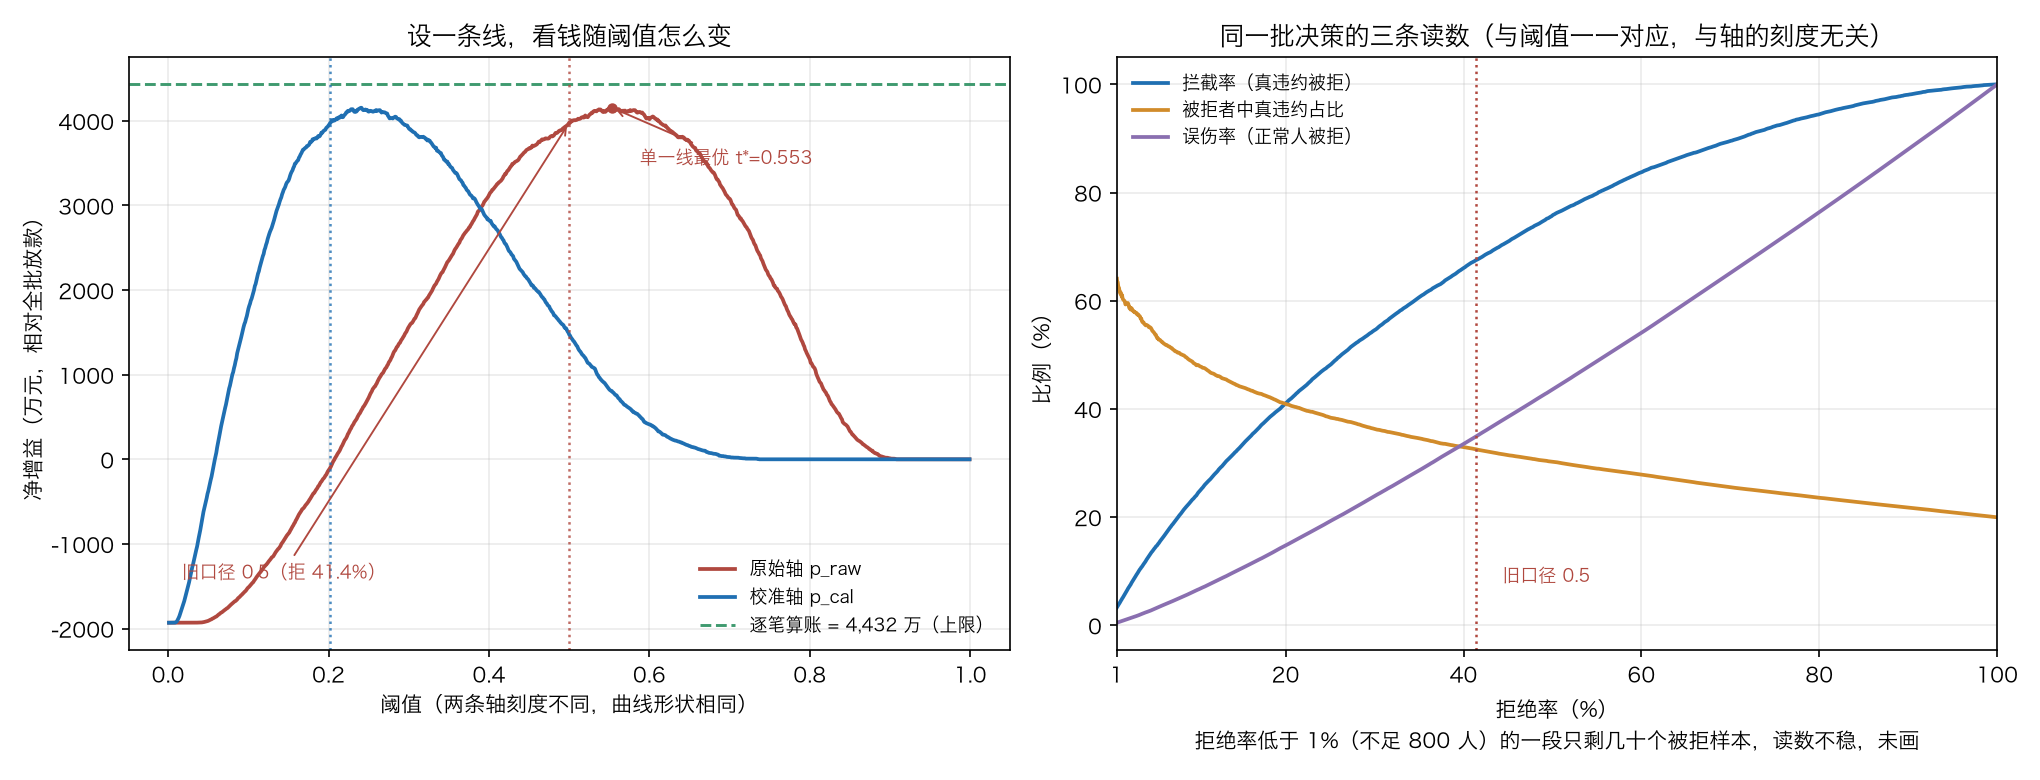

,目标拒绝率,原始轴阈值 p_raw ≥,校准轴阈值 p_cal ≥,实际拒绝率
0,0.05,0.7641,0.4659,0.05
1,0.10,0.7096,0.3933,0.10
2,0.15,0.6665,0.3441,0.15
3,0.20,0.6308,0.3080,0.20
4,0.25,0.5967,0.2766,0.25
5,0.30,0.5658,0.2507,0.30
6,0.40,0.5080,0.2075,0.40
7,0.50,0.4504,0.1704,0.50
8,0.60,0.3925,0.1379,0.60
9,0.70,0.3322,0.1083,0.70


In [21]:
# 放贷方案①：单线扫描 —— 阈值 → 人数账与钱账（原始轴，步长 0.001）
sw = pd.read_csv(OUT / "W4" / "threshold_sweep.csv")
sub = sw[sw["轴"] == "原始(未校准)"]
pick = [0.30, 0.40, 0.50, 0.55, 0.553, 0.60, 0.70]
rows = [sub.iloc[(sub["阈值"] - t).abs().argmin()] for t in pick]
display(pd.DataFrame(rows)[["阈值", "被拒占比", "拦截率", "被拒者精确率",
                            "总期望利润(万元)", "净增益_实现值(万元)"]].round(4))
display(Image(str(OUT / "W4" / "threshold_sweep.png"), width=760))
display(pd.read_csv(OUT / "W4" / "threshold_equiv.csv").round(4))


**三个读数**：① 0.5 这个数拍偏了，比最优单线少赚 189 万元（6,155 → 6,344 万元），跟概率校准无关；
② 挑阈值用的是哪条数据要交代清楚——0.553 是在测试集上扫出来的（等于拿测试集选参数，偏乐观），换成"验证集选线、测试集只跑一次"的口径：
选出 0.560、期望利润 6,342 万元，与 0.553 只差 2 万元，验证集上 0.54–0.58 是一段平台区；
③ 两个口径的绝对值不相等：0.553 处按净增益（回看）是比全放多 4,157 万元，换成期望口径是 4,259 万元，
差的 102 万元来自被拒人群实际违约率 35.5%（模型估 36.0%）。线上没有答案，落地只用期望口径。

单线再优化也只到 6,344 万元：它只能决定"拒多少人"，管不了被拒的是谁。要再往上走，得换算法——看方案②。

### 6.2 放贷方案② 逐笔期望定线：按期限拆两条线

方案②换掉"一刀切"的算法，给每笔贷款各算一笔账。**公式**：每 1 元贷款的期望利润 = (1−p) × 净收益率 × 期限 − p × (1−回收率)，期望利润 > 0 才批准。
等价于逐笔隐含阈值 `p* = 净收益率×期限 / (净收益率×期限 + 1−回收率)`——赚头厚的贷款能容忍更高的违约概率，利差薄的则要更严。
中性口径把净息差统一按 6% 算，金额在公式两边同时出现、不改变判定，赚头的差别只剩期限；本批只有 3 年期与 5 年期两种贷款，落地就是两条线。

,策略,被拒占比,拦截率(真违约被拒占比),被拒者精确率(里面真违约占比),总期望利润(万元),说明
0,全放（不筛选）,0.0000,0.0000,NaN,2085.2239,基准
1,固定阈值 0.5（未校准概率）,0.4138,0.6749,0.3254,6155.0407,第 10 节原口径
2,期望损失框架 · 乐观（利息全额）,0.0175,0.0460,0.5243,2670.4132,校准概率（回收率 30%）
3,期望损失框架 · 中性（净息差 6%）,0.3516,0.5982,0.3393,6611.4562,校准概率（回收率 30%）
4,期望损失框架 · 保守（净息差 3%）,0.6529,0.8635,0.2638,4982.5214,校准概率（回收率 30%）
5,期望损失框架（未校准概率）,0.8768,0.9735,0.2215,2109.7290,对照：不校准的后果


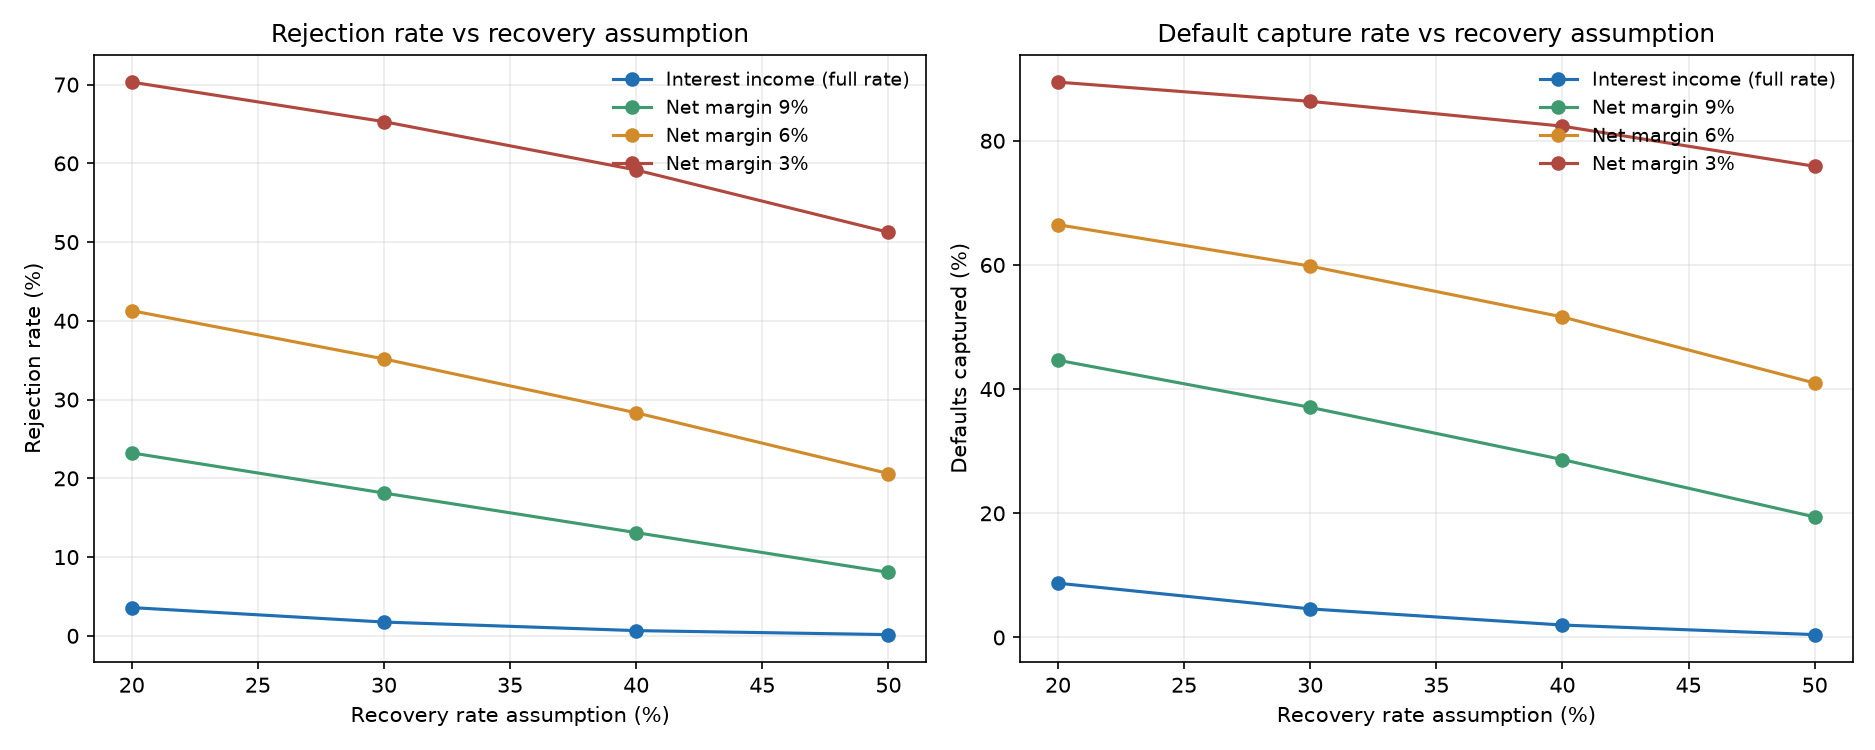

In [22]:
# 放贷方案②：逐笔期望定线 —— 每笔贷款按自己的账算，而不是全员一刀切
el = pd.read_csv(OUT / "W4" / "expected_loss_summary.csv")
display(el[["策略", "被拒占比", "拦截率(真违约被拒占比)",
            "被拒者精确率(里面真违约占比)", "总期望利润(万元)", "说明"]].round(4))
display(Image(str(OUT / "W4" / "expected_loss_sensitivity.png"), width=760))


**五条读数**：① 用未校准概率算账会拒掉 87.7% 的申请（模型被自己吓到），**校准是前提**；
② 中性口径（净息差 6%、回收率 30%）下，拒绝率 35.2% 反而低于固定阈值的 41.4%，
但总期望利润从 6,155 万升到 6,611 万——**少拒还多赚**；
③ 逐笔规则在本批数据上落地成两条线：3 年期 ≥ 0.50 拒、5 年期 ≥ 0.62 拒，
拒绝 28,078 人（35.2%），比最优单线（0.553 的 6,344 万元）多 267 万元，代价是审批系统要出两张评分表；
④ 靠线的人交人工：线上方 20% 以内的 8,697 人送复审，该段模型预估违约率 25.9%、事后实际 25.4%，全放期望利润 −295 万元；
⑤ 收益口径是最大敏感源（净息差 3% 拒 65.3%，利息全额只拒 1.8%），所以讨论阈值之前先和财务敲定口径。
净收益率与回收率是**模拟值**（数据集里没有），金额、期限、利率、是否违约才来自数据本身——本页交付的是**方法**，不是利润结论。

In [23]:
# W4 补充分析：头部区分度、时间外验证、人工复审带
display(pd.read_csv(OUT / "W4" / "head_capture.csv").round(4))
display(pd.read_csv(OUT / "W4" / "oot_validation.csv").round(4))
display(pd.read_csv(OUT / "W4" / "review_band.csv"))


,头部占比,头部人数,命中违约人数,捕获率,lift,头部内违约率
0,0.05,3992,2174,0.1365,2.7296,0.5446
1,0.10,7985,3839,0.2410,2.4101,0.4808
2,0.20,15970,6535,0.4103,2.0513,0.4092
3,0.30,23955,8693,0.5457,1.8191,0.3629


,口径,训练样本数,样本数,违约率,AUC,KS,前5%捕获率,前10%捕获率,前20%捕获率,预测概率均值,Brier,阈值0.5拒绝率,阈值0.5精确率,阈值0.5召回率
0,随机切分（对照）,664968,124550,0.1995,0.7279,0.330,0.1354,0.2406,0.4112,0.4502,0.2104,0.4190,0.3250,0.6826
1,时间外（2017-01 起）,664968,124550,0.2225,0.7184,0.319,0.1193,0.2169,0.3871,0.4589,0.2160,0.4393,0.3479,0.6868


,分工,人数,占测试集,实际违约率,说明
0,直接放行,51772,0.648366,0.123638,线以下，模型认为期望利润为正
1,人工复审,8697,0.108917,0.253996,线上方 20% 以内，模型拿不准
2,直接拒绝,19381,0.242718,0.377638,线上方 20% 以外，模型认为明显该拒


**这三张表补的是什么**：AUC 在整批人上算平均，看不出名单头部；随机切分的成绩两边行情一样，偏乐观；
拆线方案里靠线的人模型自己也没把握。

- KS 0.3269；前 10% 捕获率 24.1%（随机挑的 2.41 倍），前 30% 捕获 54.6%；
- 按放款日期切分（训练 ≤2016-12，测试 2017-01 起）后，AUC 0.7279 → 0.7184，违约率 19.9% → 22.3%，
  排序能力没垮，概率刻度会漂，上线后要定期重标定；
- 复审带 8,697 人（占被拒 28,078 人的 31.0%）：这撮人不挑不拣全放，期望利润 −295 万元；
  把里面 6,488 名正常人挑出来放，是 2,188 万元息差——复审带的价值就在这两头之间。

In [24]:
# 活代码复现：用最终参数重训 LightGBM，验证测试集指标与成绩单一致（约 30 秒）
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)
from lightgbm import LGBMClassifier

X = df.drop(columns=["isDefault"]); y = df["isDefault"]
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=1/3, stratify=y_temp, random_state=42)

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
best_params = {"subsample": 0.8, "num_leaves": 63, "n_estimators": 200,
               "max_depth": 8, "learning_rate": 0.05, "colsample_bytree": 0.7}
model = LGBMClassifier(**best_params, scale_pos_weight=scale_pos,
                       verbosity=-1, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
p = model.predict_proba(X_test)[:, 1]
pred = (p >= 0.5).astype(int)
print("复现: acc=%.4f prec=%.4f rec=%.4f f1=%.4f auc=%.4f" % (
    accuracy_score(y_test, pred), precision_score(y_test, pred),
    recall_score(y_test, pred), f1_score(y_test, pred), roc_auc_score(y_test, p)))
print("官方: acc=0.6560 prec=0.3254 rec=0.6749 f1=0.4390 auc=0.7249")


复现: acc=0.6560 prec=0.3254 rec=0.6749 f1=0.4390 auc=0.7249
官方: acc=0.6560 prec=0.3254 rec=0.6749 f1=0.4390 auc=0.7249


## 7. 业务结论与交付

### 阈值怎么选（6.2 风险阈值选择）
- 阈值 0.5（默认平衡档）：拒绝约 41% 的申请，拦下 67.5% 的违约者，误伤约 35% 的正常客户
- 阈值 0.3（宽进）：拦下 92.3% 违约者，但误伤翻倍，适合获客扩张期
- 阈值 0.7（严审）：精确率 47.4%（误伤少），但漏掉约 74% 违约者，适合风险收缩期
- **起手线 0.55**：从 0.50 挪到 0.55 少拒 6,944 人，期望利润 6,155 万 → 6,340 万；改用验证集选线，0.560 对应 6,342 万元，平台区 0.54–0.58
- **能拆线就拆**：按贷款期限设两条线（3 年期 0.50 / 5 年期 0.62），期望利润 6,611 万元，比最优单线多 267 万元（见第 6 节）
- **靠线的交人工**：线上方 20% 以内的 8,697 人送复审，其余 71,153 人由机器直接判
- **最终选择**：算法给定档位，最终数字要由机构用真实回收率与资金成本敲定；报告中给出了完整框架与敏感性分析，参数本身是模拟值

### 给业务方的话
1. 模型在从未见过的测试集上 AUC 0.7249，训练/验证/测试差距小，**没有过拟合**，可稳定推广到新客户
2. 与随机拒绝相比，同等拒绝比例下多拦下约 26 个百分点的违约者，同时少误伤约 6 个百分点
3. 最重要特征：subGrade（等级）、term（期限）、homeOwnership、fico（信用分）——**放贷时可优先核对这几项**
4. 局限：数据集字段有限（部分匿名/脱敏），AUC 0.72 属同数据规模下的合理水平；提升需接入征信局数据、还款行为序列特征


In [25]:
# 业务仪表板（4 个页签）
print("运行仪表板：.venv/bin/python -m streamlit run scripts/W4/app_dashboard.py")
print("页面：① 数据概览（EDA）")
print("      ② 模型表现（成绩单与 KS/头部捕获率/泛化/性能图/时间外验证/模型对比/特征重要性/调参/特征数量）")
print("      ③ 放贷方案① 单一线：一条线管所有人（阈值滑块 + 回收率/净息差，人数账与净增益）")
print("      ④ 放贷方案② 拆线：按期限设两条线（概率校准/分箱对照/逐笔算账/敏感性/两条线对比/复审带/上线清单）")
print("离线版：outputs/W4/dashboard.html（双击即开，无需环境）")


运行仪表板：.venv/bin/python -m streamlit run scripts/W4/app_dashboard.py
页面：① 数据概览（EDA）
      ② 模型表现（成绩单与 KS/头部捕获率/泛化/性能图/时间外验证/模型对比/特征重要性/调参/特征数量）
      ③ 放贷方案① 单一线：一条线管所有人（阈值滑块 + 回收率/净息差，人数账与净增益）
      ④ 放贷方案② 拆线：按期限设两条线（概率校准/分箱对照/逐笔算账/敏感性/两条线对比/复审带/上线清单）
离线版：outputs/W4/dashboard.html（双击即开，无需环境）


### 交付清单对照
- **代码**：`data_preprocessing.py`（W1）｜`feature_engineering.py`、`model_training.py`（W2）｜`model_optimization.py`（W3）｜`model_final_eval.py`、`learning_curve.py`、`prepare_test_predictions.py`、`probability_calibration.py`、`threshold_sweep.py`、`threshold_select_on_val.py`、`expected_loss_framework.py`、`feature_count_auc.py`、`head_capture.py`、`oot_validation.py`、`review_band.py`、`pricing_headroom.py`、`app_dashboard.py`、`build_dashboard_html.py`、`report_figures.py`（W4）｜本 Notebook（由 `build_main_pipeline.py` 生成）
- **报告**：数据探索报告 / 特征工程报告 / 模型评估报告 / 模型优化报告 / 最终项目报告（`reports/`）
- **可视化**：EDA 图（W1）、特征重要性（W2）、ROC/PR/混淆矩阵/学习曲线（W2/W4）、SHAP（W3）、校准曲线、阈值扫描曲线与期望损失敏感性（W4）、KS 与头部捕获率（W4）、离线单文件仪表板 `outputs/W4/dashboard.html`（W4，4 个页签）
- **文档**：`README.md`、`requirements.txt`、`outputs/W4/信贷违约模型与审批线_W4汇报.pptx`（15 页，附同名 PDF；deck 工程在 `.cache/ppt/w4-deck_20260924/`，报告与周报的 docx 由 `scripts/tools/md_to_house_docx.py` 从同名 md 生成）
